PART 1: K-MEANS CLUSTERING

Original K-Means Dataset:
   Feature_1  Feature_2
0  -7.155244  -7.390016
1  -7.395875  -7.110843
2  -2.015671   8.281780
3   4.509270   2.632436
4  -8.102502  -7.484961


C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

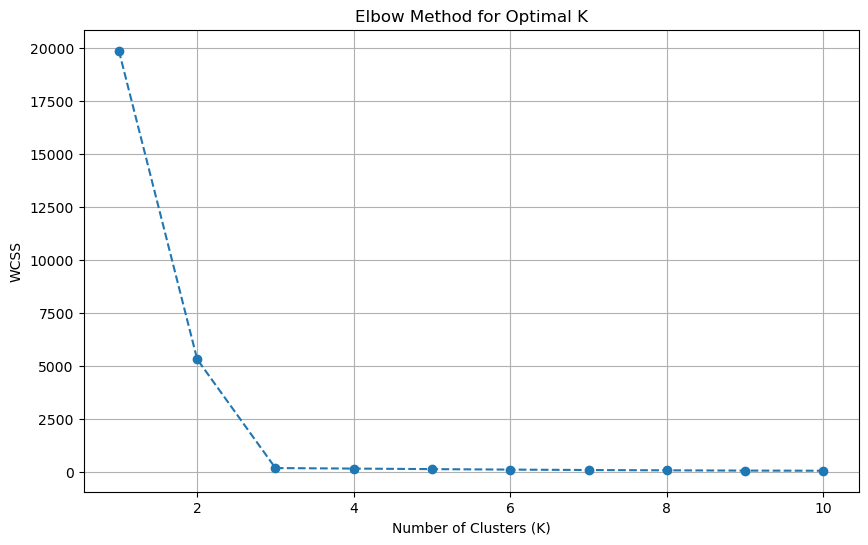

C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



K-Means Clustering Completed


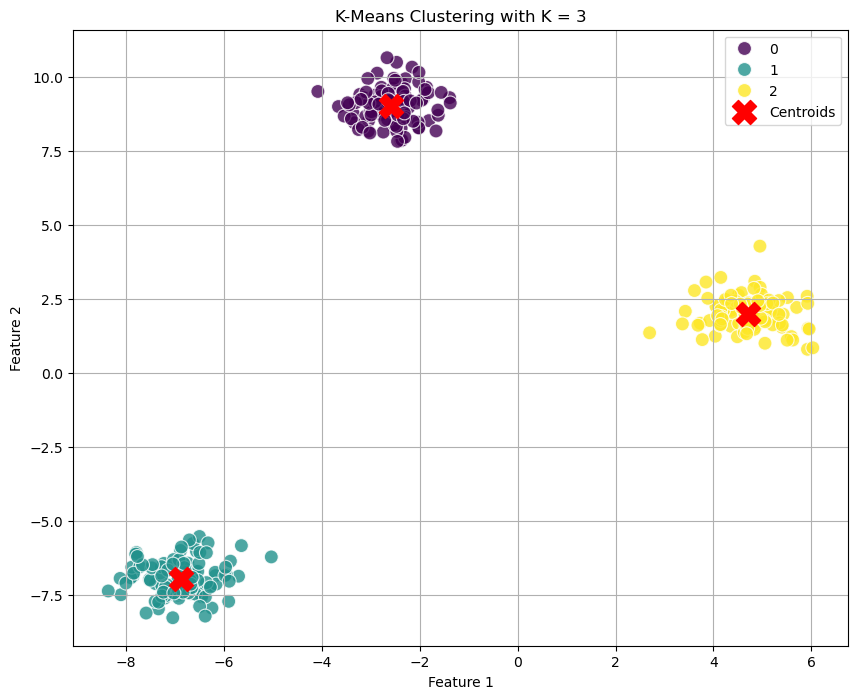


Silhouette Score for K-Means: 0.908


PART 2: PRINCIPAL COMPONENT ANALYSIS (PCA)

Original PCA Dataset:
   Feature_1  Feature_2  Feature_3  Feature_4  True_Cluster
0  -0.638667   1.110057  -6.400722  -0.204990             3
1  -2.951556  -7.657445   3.844794   0.903589             1
2  -0.253177   2.125103  -7.869801   0.559678             3
3  -2.151209   3.401400  -5.734930   0.965230             3
4  -2.347519  -7.230467   3.478891  -0.443440             1

Original PCA Dataset Shape: (500, 5)

Data Standardization Completed

Principal Components:
   Principal_Component_1  Principal_Component_2  True_Cluster
0               0.455305               1.623917             3
1              -2.705622               0.375012             1
2               0.810234               1.966926             3
3               0.427139               2.149626             3
4              -2.407508               0.099250             1

Explained Variance Ratio: [0.57208431 0.33622342]
Total Explained Var

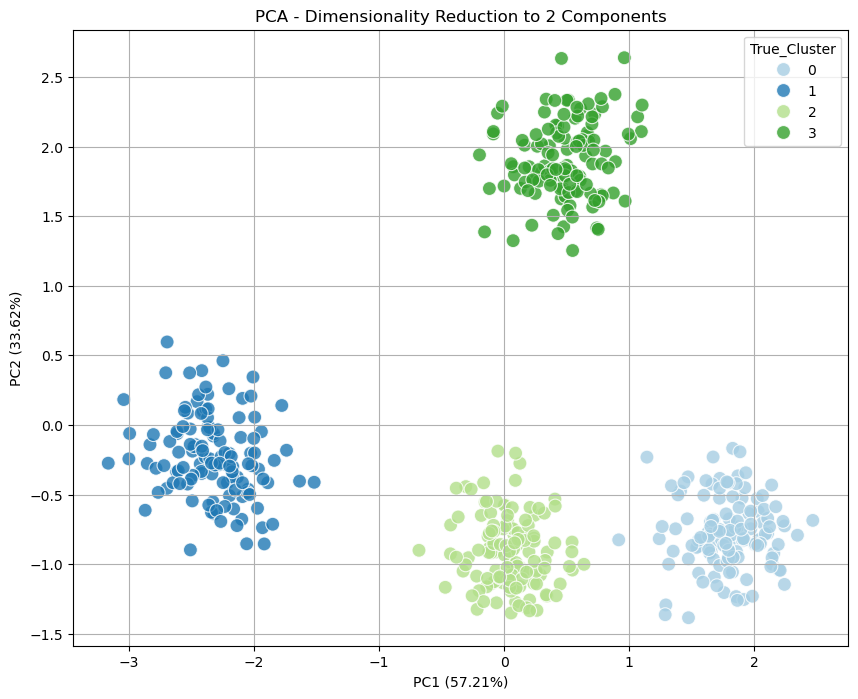

C:\Users\Lenovo\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


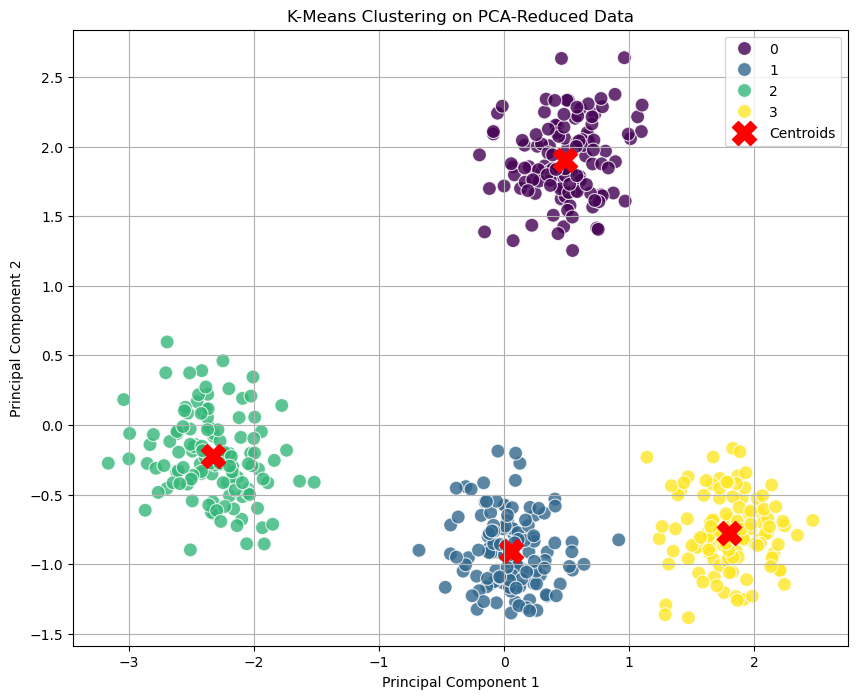


Silhouette Score for K-Means on PCA-Reduced Data: 0.776


EXPERIMENT 5 COMPLETED SUCCESSFULLY


In [1]:
# ============================================================
# EXPERIMENT 5
# CLUSTERING WITH K-MEANS AND DIMENSIONALITY REDUCTION WITH PCA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# ============================================================
# PART 1: K-MEANS CLUSTERING
# ============================================================

print("=" * 60)
print("PART 1: K-MEANS CLUSTERING")
print("=" * 60)


# 1. Generate dataset
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=42
)

df_kmeans = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

print("\nOriginal K-Means Dataset:")
print(df_kmeans.head())


# ============================================================
# 2. ELBOW METHOD
# ============================================================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o",
    linestyle="--"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)

plt.show()


# ============================================================
# 3. APPLY K-MEANS WITH K = 3
# ============================================================

optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df_kmeans["Cluster"] = clusters

print("\nK-Means Clustering Completed")


# ============================================================
# 4. VISUALIZE K-MEANS CLUSTERS
# ============================================================

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x="Feature_1",
    y="Feature_2",
    hue="Cluster",
    data=df_kmeans,
    palette="viridis",
    s=100,
    alpha=0.8
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("K-Means Clustering with K = 3")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 5. SILHOUETTE SCORE
# ============================================================

silhouette_avg = silhouette_score(
    X,
    clusters
)

print(
    f"\nSilhouette Score for K-Means: "
    f"{silhouette_avg:.3f}"
)


# ============================================================
# PART 2: PCA
# ============================================================

print("\n")
print("=" * 60)
print("PART 2: PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 60)


# ============================================================
# 1. GENERATE 4D DATASET
# ============================================================

X_pca, y_pca = make_blobs(
    n_samples=500,
    n_features=4,
    centers=4,
    cluster_std=1.0,
    random_state=25
)

df_pca_original = pd.DataFrame(
    X_pca,
    columns=[
        "Feature_1",
        "Feature_2",
        "Feature_3",
        "Feature_4"
    ]
)

df_pca_original["True_Cluster"] = y_pca

print("\nOriginal PCA Dataset:")
print(df_pca_original.head())

print(
    "\nOriginal PCA Dataset Shape:",
    df_pca_original.shape
)


# ============================================================
# 2. STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

X_pca_scaled = scaler.fit_transform(X_pca)

print("\nData Standardization Completed")


# ============================================================
# 3. PCA: 4D -> 2D
# ============================================================

pca = PCA(n_components=2)

principal_components = pca.fit_transform(
    X_pca_scaled
)

df_principal_components = pd.DataFrame(
    principal_components,
    columns=[
        "Principal_Component_1",
        "Principal_Component_2"
    ]
)

df_principal_components["True_Cluster"] = y_pca


# Explained variance
explained_variance = pca.explained_variance_ratio_

print("\nPrincipal Components:")
print(df_principal_components.head())

print(
    "\nExplained Variance Ratio:",
    explained_variance
)

print(
    "Total Explained Variance by 2 PCs:",
    f"{explained_variance.sum():.3f}"
)


# ============================================================
# 4. VISUALIZE PCA RESULT
# ============================================================

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x="Principal_Component_1",
    y="Principal_Component_2",
    hue="True_Cluster",
    data=df_principal_components,
    palette="Paired",
    s=100,
    alpha=0.8
)

plt.title(
    "PCA - Dimensionality Reduction to 2 Components"
)

plt.xlabel(
    f"PC1 ({explained_variance[0] * 100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1] * 100:.2f}%)"
)

plt.grid(True)

plt.show()


# ============================================================
# 5. K-MEANS ON PCA-REDUCED DATA
# ============================================================

kmeans_pca = KMeans(
    n_clusters=4,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42
)

clusters_pca = kmeans_pca.fit_predict(
    principal_components
)

df_principal_components[
    "KMeans_Cluster_on_PCA"
] = clusters_pca


# ============================================================
# VISUALIZE K-MEANS ON PCA DATA
# ============================================================

plt.figure(figsize=(10, 8))

sns.scatterplot(
    x="Principal_Component_1",
    y="Principal_Component_2",
    hue="KMeans_Cluster_on_PCA",
    data=df_principal_components,
    palette="viridis",
    s=100,
    alpha=0.8
)

plt.scatter(
    kmeans_pca.cluster_centers_[:, 0],
    kmeans_pca.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title(
    "K-Means Clustering on PCA-Reduced Data"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 6. SILHOUETTE SCORE FOR PCA + K-MEANS
# ============================================================

silhouette_avg_pca = silhouette_score(
    principal_components,
    clusters_pca
)

print(
    "\nSilhouette Score for K-Means on PCA-Reduced Data:",
    f"{silhouette_avg_pca:.3f}"
)


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 60)
print("EXPERIMENT 5 COMPLETED SUCCESSFULLY")
print("=" * 60)